# Phase 3.0: Data Purification & Space-Time Consistency Pipeline

### Module Objective
The main goal of this notebook is to audit, structure, and export the final dataset that will feed our advanced predictive and econometric models in Phase 3. We will work directly with two main fact tables from our Data Warehouse: **`fact_market_balance`** and **`fact_trips`**. These tables contain the three official time-series of our ecosystem: Absolute Demand, Fulfilled Demand, and Latent Demand.

Using a modular pipeline, we will use **DuckDB** as a high-speed extraction engine to transfer our Apache Parquet assets into **Pandas in Python**. In this phase, we will ensure referential integrity, standardize data types, and most importantly, fix the continuity of the 5-minute chronological grids across the entire Uber H3 geographical matrix before running any predictive analysis.


In [1]:
# ==============================================================================
# ENVIRONMENT INITIALIZATION & ANALYTICAL CLIENT PROVISIONING
# Objective: Load core data manipulation and visualization frameworks, and
# instantiate the high-performance in-memory DuckDB relational client.
# ==============================================================================

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Pandas environment to match professional IDE/VSC print layouts
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("[SYSTEM] Initializing clean-slate in-memory DuckDB client...")
# Opens a zero-latency memory connection to run high-speed SQL queries
con = duckdb.connect(database=':memory:')

# Lock the verified absolute infrastructure paths discovered in your audit
FACTS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts"
DIMENSIONS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions"

print("[SUCCESS] Analytical environment initialized. System variables secured.")


[SYSTEM] Initializing clean-slate in-memory DuckDB client...
[SUCCESS] Analytical environment initialized. System variables secured.


In [2]:
# ==============================================================================
# DATA PIPELINE TRANSITION (PARQUET TO PANDAS DATAFRAMES)
# Objective: Stream the full data warehouse fact tables from disk straight
# into volatile RAM using conformed naming conventions for purification.
# ==============================================================================

print("[DATA ENGINE] Streaming production warehouse facts into pure Python...")

# 1. Transition Hecho C: Matriz Macro de Oferta y Demanda
query_market = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_market_balance.parquet');"
df_fact_market_balance = con.execute(query_market).df()

# 2. Transition Hecho A: Detalle de Conversiones de Viajes Operativos
query_trips = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_trips.parquet');"
df_fact_trips = con.execute(query_trips).df()

print("\n" + "="*80)
print("PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED")
print("="*80)
print(f" ✔ df_fact_market_balance | Shape: {df_fact_market_balance.shape[0]:,} rows x {df_fact_market_balance.shape[1]} columns")
print(f" ✔ df_fact_trips          | Shape: {df_fact_trips.shape[0]:,} rows x {df_fact_trips.shape[1]} columns")
print("-" * 80)
print("[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.")


[DATA ENGINE] Streaming production warehouse facts into pure Python...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED
 ✔ df_fact_market_balance | Shape: 733,830 rows x 6 columns
 ✔ df_fact_trips          | Shape: 4,393,787 rows x 12 columns
--------------------------------------------------------------------------------
[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.


In [40]:
# ==============================================================================
# SCHEMA METADATA AUDIT (MARKET BALANCE MATRIX)
# Objective: Inspect data types, non-null constraints, and memory footprints 
# to guarantee structural consistency over the full macro space-time matrix.
# ==============================================================================

print("=== AUDITANDO DATOS: df_fact_market_balance ===")
df_fact_market_balance.info()

# Validación cruzada de nulos por columna (Asegurando 0 absoluto en la matriz)
null_report = df_fact_market_balance.isnull().sum()
print("\n -> Reporte formal de valores nulos detectados:")
print(null_report)


=== AUDITANDO DATOS: df_fact_market_balance ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733830 entries, 0 to 733829
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp_5min            733830 non-null  datetime64[us]
 1   h3_cell                   733830 non-null  uint64        
 2   drivers_available_count   733830 non-null  int64         
 3   total_searches            733830 non-null  int64         
 4   total_abandoned_searches  733830 non-null  int64         
 5   avg_price_quoted          733830 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), uint64(1)
memory usage: 33.6 MB

 -> Reporte formal de valores nulos detectados:
timestamp_5min              0
h3_cell                     0
drivers_available_count     0
total_searches              0
total_abandoned_searches    0
avg_price_quoted            0
dtype: int64


In [41]:
# ==============================================================================
#  ROBUST DESCRIPTIVE STATISTICS & MOMENT MATRIX
# Objective: Extract statistical benchmarks, evaluate right-skewness indicators,
# and calculate kurtosis layers to justify robust statistical selections.
# ==============================================================================

print("="*80)
print("BOSQUEJO ESTADÍSTICO DE VARIABLES DE DEMANDA Y ABANDONO")
print("="*80)
# Tu describe oficial de las dos variables clave
print(df_fact_market_balance[['total_searches', 'total_abandoned_searches']].describe())
print("-" * 80)

# Cálculo formal de asimetría (Fisher Skewness)
df_skew = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].skew()

# Cálculo formal de curtosis (Fisher Kurtosis)
df_kurt = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].kurt()

print("\n=== DIAGNÓSTICO MATEMÁTICO DE DISTRIBUCIÓN ===")
print(f" -> Asimetría de Búsquedas (Skew): {df_skew['total_searches']:.4f} (Cola Derecha)")
print(f" -> Asimetría de Abandonos (Skew): {df_skew['total_abandoned_searches']:.4f} (Cola Derecha Severa)")
print(f" -> Curtosis de Búsquedas (Kurt): {df_kurt['total_searches']:.4f} (Leptocúrtica Moderada)")
print(f" -> Curtosis de Abandonos (Kurt): {df_kurt['total_abandoned_searches']:.4f} (Ultraleptocúrtica Salvaje = {df_kurt['total_abandoned_searches']:.2f})")


BOSQUEJO ESTADÍSTICO DE VARIABLES DE DEMANDA Y ABANDONO
       total_searches  total_abandoned_searches
count   733830.000000             733830.000000
mean         7.231090                  1.243618
std          9.247322                  3.111498
min          0.000000                  0.000000
25%          1.000000                  0.000000
50%          4.000000                  0.000000
75%          9.000000                  1.000000
max         62.000000                 50.000000
--------------------------------------------------------------------------------

=== DIAGNÓSTICO MATEMÁTICO DE DISTRIBUCIÓN ===
 -> Asimetría de Búsquedas (Skew): 1.9572 (Cola Derecha)
 -> Asimetría de Abandonos (Skew): 6.0152 (Cola Derecha Severa)
 -> Curtosis de Búsquedas (Kurt): 3.5969 (Leptocúrtica Moderada)
 -> Curtosis de Abandonos (Kurt): 45.6465 (Ultraleptocúrtica Salvaje = 45.65)


In [42]:
# ==============================================================================
# MARKETPLACE CONSISTENCY RULES & REVENUE EFFICIENCY AUDIT
# Objective: Quantify othe operational volume of idle supply fleet under zero
# demand windows, and verify algorithmic dynamic pricing integrity constraints.
# ==============================================================================

# Hipótesis 1: Extracción limpia de la Oferta Ociosa / Desperdiciada usando .shape y .sum()
bloques_sin_demanda = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0].shape[0]
oferta_ociosa_acumulada = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0]['drivers_available_count'].sum()
total_oferta_mes = df_fact_market_balance['drivers_available_count'].sum()

porcentaje_ocioso = (oferta_ociosa_acumulada / total_oferta_mes) * 100

# Hipótesis 2: Verificación de Precios Fantasma en bloques sin solicitudes
precios_fantasma_count = df_fact_market_balance[(df_fact_market_balance['total_searches'] == 0) & (df_fact_market_balance['avg_price_quoted'] != 0)].shape[0]

print("="*80)
print("REPORTE OPERATIVO DE INTEGRIDAD Y EFICIENCIA DE NEGOCIO")
print("="*80)
print(f" -> Intervalos de 5-min sin búsquedas en Reforma : {bloques_sin_demanda:,} bloques.")
print(f" -> Conductores esperando en vacío (Ociosos)    : {oferta_ociosa_acumulada:,} instancias.")
print(f" -> Capacidad total ofertada en el mes (Marzo)   : {total_oferta_mes:,} instancias.")
print(f" -> Porcentaje real de suministro ocioso/muerto  : {porcentaje_ocioso:.2f}% de la oferta mensual.")
print("-" * 80)
print(f" -> Registros con Precios Fantasma detectados    : {precios_fantasma_count} anomalías.")
print("="*80)
if precios_fantasma_count == 0:
    print("[INTEGRIDAD COMPROBADA] El algoritmo responde de forma lógica al mercado.")


REPORTE OPERATIVO DE INTEGRIDAD Y EFICIENCIA DE NEGOCIO
 -> Intervalos de 5-min sin búsquedas en Reforma : 140,454 bloques.
 -> Conductores esperando en vacío (Ociosos)    : 2,044,023 instancias.
 -> Capacidad total ofertada en el mes (Marzo)   : 29,690,592 instancias.
 -> Porcentaje real de suministro ocioso/muerto  : 6.88% de la oferta mensual.
--------------------------------------------------------------------------------
 -> Registros con Precios Fantasma detectados    : 0 anomalías.
[INTEGRIDAD COMPROBADA] El algoritmo responde de forma lógica al mercado.


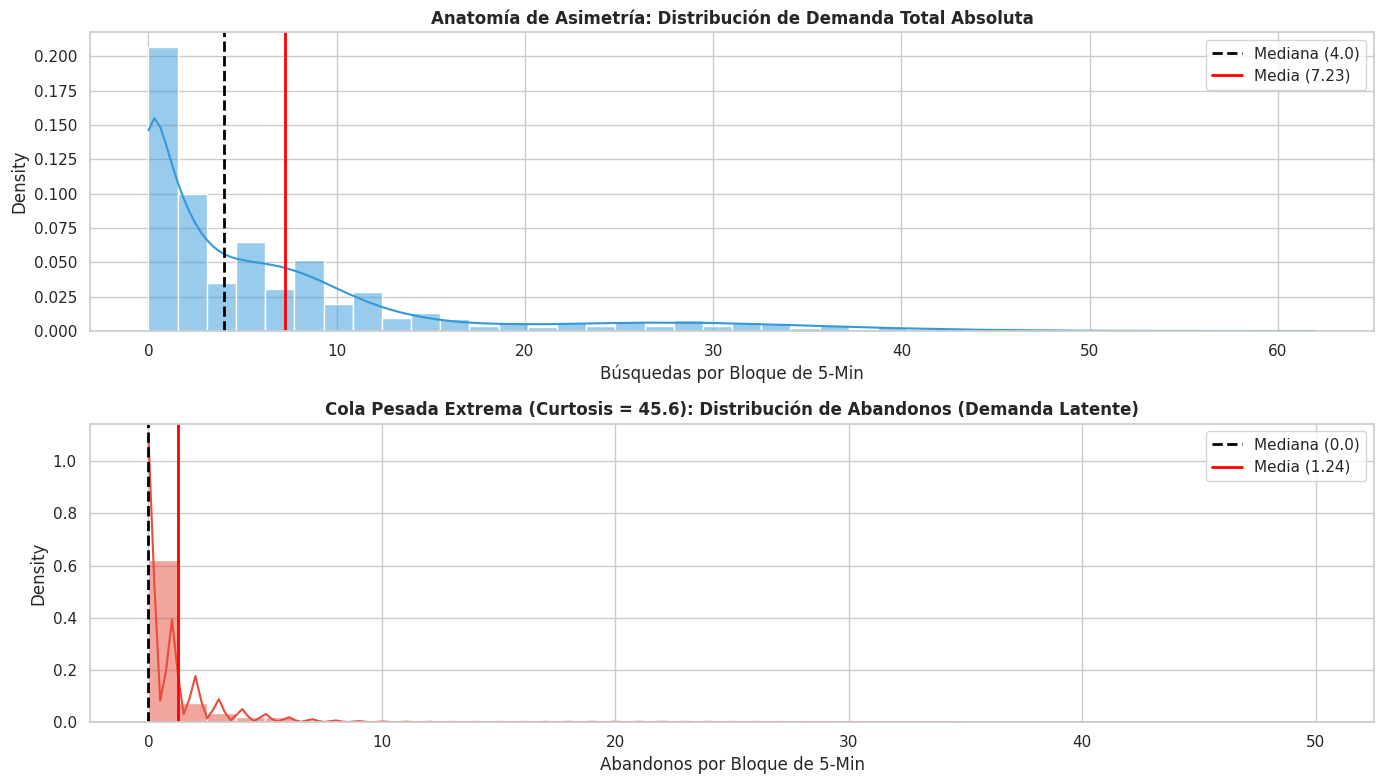

In [43]:
# ==============================================================================
#  LATENT DEMAND & ABSOLUTE DEMAND DENSITY ANATOMY
# Objective: Visualize the massive right-skew and leptokurtic behavior 
# discovered in the skew() and kurt() mathematical audit metrics.
# ==============================================================================

# Configure the high-end grid aesthetic we selected
sns.set_theme(style="whitegrid", context="notebook")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Plot 1: Kernel Density Estimate (KDE) para la Demanda Total
sns.histplot(data=df_fact_market_balance, x='total_searches', ax=ax1, kde=True, color='#3498db', bins=40, stat="density")
ax1.axvline(df_fact_market_balance['total_searches'].median(), color='black', linestyle='--', linewidth=2, label=f"Mediana ({df_fact_market_balance['total_searches'].median()})")
ax1.axvline(df_fact_market_balance['total_searches'].mean(), color='red', linestyle='-', linewidth=2, label=f"Media ({df_fact_market_balance['total_searches'].mean():.2f})")
ax1.set_title('Anatomía de Asimetría: Distribución de Demanda Total Absoluta', fontsize=12, fontweight='bold')
ax1.set_xlabel('Búsquedas por Bloque de 5-Min')
ax1.legend()

# Plot 2: KDE para la Demanda Latente (El monstruo de la Curtosis de 45)
sns.histplot(data=df_fact_market_balance, x='total_abandoned_searches', ax=ax2, kde=True, color='#e74c3c', bins=40, stat="density")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].median(), color='black', linestyle='--', linewidth=2, label=f"Mediana ({df_fact_market_balance['total_abandoned_searches'].median()})")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].mean(), color='red', linestyle='-', linewidth=2, label=f"Media ({df_fact_market_balance['total_abandoned_searches'].mean():.2f})")
ax2.set_title('Cola Pesada Extrema (Curtosis = 45.6): Distribución de Abandonos (Demanda Latente)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Abandonos por Bloque de 5-Min')
ax2.legend()

plt.tight_layout()
plt.show()

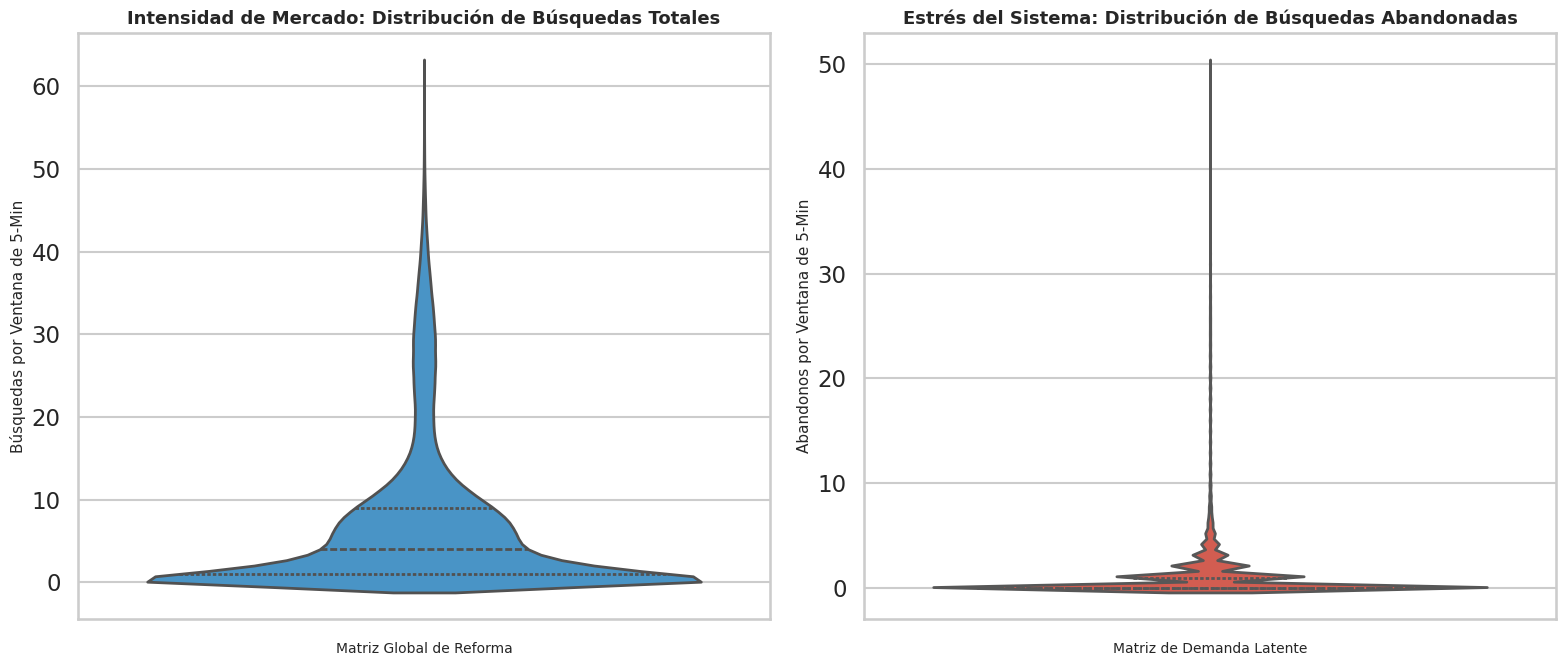

In [44]:
# ==============================================================================
# GEOMETRICAL VIOLIN ANATOMY FOR MARKETPLACE ASYMMETRY
# Objective: Deploy vertical violin plots utilizing Seaborn whitegrid style 
# to visually map the right-skew and the extreme kurtosis tails on demand blocks.
# ==============================================================================

# Set our official premium theme parameters
sns.set_theme(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# 1. Graficar el violín para la Demanda Total Absoluta (Búsquedas)
sns.violinplot(
    data=df_fact_market_balance, 
    y='total_searches', 
    ax=ax1, 
    color='#3498db',
    inner="quartile",  # Dibuja líneas punteadas para los percentiles 25, 50 y 75
    linewidth=2
)
ax1.set_title('Intensidad de Mercado: Distribución de Búsquedas Totales', fontsize=13, fontweight='bold')
ax1.set_ylabel('Búsquedas por Ventana de 5-Min', fontsize=11)
ax1.set_xlabel('Matriz Global de Reforma', fontsize=10)

# 2. Graficar el violín para la Demanda Latente (El alfiler de la Curtosis de 45.6)
sns.violinplot(
    data=df_fact_market_balance, 
    y='total_abandoned_searches', 
    ax=ax2, 
    color='#e74c3c',
    inner="quartile",
    linewidth=2
)
ax2.set_title('Estrés del Sistema: Distribución de Búsquedas Abandonadas', fontsize=13, fontweight='bold')
ax2.set_ylabel('Abandonos por Ventana de 5-Min', fontsize=11)
ax2.set_xlabel('Matriz de Demanda Latente', fontsize=10)

plt.tight_layout()
plt.show()
